[![Apri in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/riccardoberta/regressione/blob/main/02_primo_scout_automatico.ipynb)

# Il primo scout automatico

Nel primo notebook abbiamo **guardato i dati**: ora vogliamo **costruire qualcosa** che li usi. Lavoreremo sugli stessi dati del primo notebook. È una scelta consapevole: con il dataset già familiare, possiamo dedicare tutta l'attenzione alla novità, l'algoritmo che prova a **prevedere** il valore di mercato. 

Carichiamo nuovamente i dati e applichiamo la stessa pulizia del primo notebook: teniamo solo le colonne utili, eliminiamo le righe senza valore di mercato e tagliamo via l'1% di giocatori più costosi:

In [212]:
# Librerie necessarie per scaricare ed estrarre il dataset
import urllib.request, zipfile
from pathlib import Path

# Librerie per l'analisi dei dati e la visualizzazione
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Link al dataset e percorsi locali
DATA_URL = (
    "https://www.dropbox.com/scl/fi/0l5n46qjwcd5moj3w7d8p/"
    "fifa.zip?rlkey=rcqhagvq5ttlvna5t5r3vn1bm&st=uzplzs5o&dl=1"
)
ZIP_PATH = Path("fifa.zip")
DATA_DIR = Path("fifa_data")

# Scarichiamo il dataset se non è già presente
if not ZIP_PATH.exists():
    print("Scarico il dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

# Estraiamo il dataset se non è già stato fatto
if not list(DATA_DIR.rglob("*.csv")):
    DATA_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)

# Cerchiamo il file CSV dei giocatori dentro la cartella estratta
csv_files = (
    list(DATA_DIR.rglob("players_22.csv"))
    or list(DATA_DIR.rglob("*players*.csv"))
)

# Carichiamo il CSV in un DataFrame pandas: ogni riga = un giocatore
raw_data = pd.read_csv(csv_files[0], low_memory=False)

# Definiamo un sottoinsieme di colonne che ci interessano
wanted_columns = [
    "short_name", "age", "overall", "potential", "wage_eur", "value_eur",
    "club_name", "league_name", "player_positions"
]

# Prendiamo solo le colonne che ci interessano e copiamo il dataset
# per lavorarci sopra senza modificare l'originale
dataset = raw_data[wanted_columns].copy()

# Manteniamo solo i giocatori con valore noto e positivo
dataset = dataset.dropna(subset=["value_eur", "age", "overall", "potential"])
dataset = dataset[dataset["value_eur"] > 0]

# Riduciamo l'effetto dei super-giocatori (l'1% più costoso)
dataset = dataset[dataset["value_eur"] <= dataset["value_eur"].quantile(0.99)]

# Per leggibilità usiamo il valore in milioni di euro
dataset["value_mln_eur"] = dataset["value_eur"] / 1_000_000
if "wage_eur" in dataset.columns:
    dataset["wage_k_eur"] = dataset["wage_eur"] / 1_000

Il problema che vogliamo affrontare consiste nel prevedere un valore target (nel nostro caso il valore di mercato) a partire dalle feature disponibili, cioè dalle informazioni sui giocatori. Questo tipo di problema prende il nome di **regressione**.

L’obiettivo è costruire un modello capace di prendere in ingresso un insieme di valori per le feature $x$ e restituire in output una stima del valore di mercato $\hat{y}$, cioè una previsione del valore reale $y$:

$\displaystyle \hat{y} = f(x)$

Per riuscirci, è necessario innanzitutto organizzare i dati in modo coerente con questa struttura: da una parte le variabili in ingresso $x$ (le feature), dall’altra la variabile da prevedere $y$ (il target). A questo punto entra in gioco una scelta fondamentale: definire la forma della funzione $f$, cioè il **tipo di modello** che utilizzeremo per descrivere la relazione tra input e output.

## I dati e il modello

Sulla base dell’analisi svolta, sappiamo che l’overall è la variabile che mostra il legame più forte con il valore di mercato $y$. Per questo motivo la scegliamo come unica feature del nostro input $x$. A partire da questa scelta, costruiamo un modello estremamente essenziale: una formula che, utilizzando un solo indizio (l’overall), produce una stima del valore di mercato in milioni di euro, assumendo una **relazione lineare**, cioè che il valore cresce in modo proporzionale all’overall.

### Input e target

Separiamo con chiarezza due ruoli: da una parte le colonne che usiamo come **indizi** (gli input), dall’altra la colonna che vogliamo **prevedere** (il target). Questa distinzione può sembrare banale, ma è alla base di qualsiasi problema di machine learning: si tratta sempre di indicare all’algoritmo quali informazioni osservare e quale quantità stimare.

In [119]:
# x = la feature che useremo per prevedere il valore di mercato, l'overall del giocatore
x = dataset["overall"]

# y = il target da prevedere, il valore di mercato in milioni
y = dataset["value_mln_eur"]

x.head(), y.head()

(7     90
 22    88
 26    88
 31    87
 32    87
 Name: overall, dtype: int64,
 7     13.5
 22    24.0
 26    15.5
 31    13.5
 32    32.0
 Name: value_mln_eur, dtype: float64)

### Scegliamo un tipo di modello

Fermiamoci un attimo a riflettere su una scelta fondamentale: che tipo di relazione stiamo cercando tra input e output? In altre parole, **quale forma vogliamo dare al nostro modello?** Dato che al crescere dell'overall il valore di mercato tende ad aumentare, facciamo un'**ipotesi** semplice: il target varia in modo lineare rispetto a x. Questo significa assumere che il legame tra le due grandezze possa essere descritto da una retta, cioè da una funzione della forma:

$\displaystyle \hat{y} = f(x) = w \; x + b$

dove:

- $\hat{y}$ è la previsione del modello
- $w$ è la pendenza della retta, di quanto cresce la previsione quando l’input aumenta di una unità
- $b$ è l’intercetta: il valore previsto quando $x=0$

Prepariamo del codice che ci permetta di visualizzare una retta dati i suoi parametri $w$ e $b$ sopra i dati, in modo da poter vedere come si comporta la nostra ipotesi di linearità. 

In [ ]:
# Funzione per disegnare una retta
def plot_line_with_data(w=1.0, b=0.0):

    plt.figure(figsize=(6,4))
    
    # Disegniamo i dati reali come punti
    plt.scatter(x, y, alpha=0.2, label="Dati")
    
    # Creiamo una serie di punti x e calcoliamo i corrispondenti y sulla retta 
    x_values = list(range(0, x.max() + 1))
    y_hat = [w * xi + b for xi in x_values]
    
    # Disegniamo la retta
    plt.plot(x_values, y_hat, color="red", label="Modello")
    
    # Impostiamo i limiti degli assi per vedere bene i dati e la retta
    plt.xlim(0, x.max())
    plt.ylim(0, y.max())

    # Aggiungiamo titolo, etichette, griglia e legenda
    plt.title(f"w = {w:.2f}, b = {b:.2f}")
    plt.xlabel("overall")
    plt.ylabel("Valore di mercato [milioni di euro]")
    plt.grid(True)
    plt.legend()

    # Mostriamo il grafico
    plt.show()

Usiamo il codice che abbiamo predisposto per disegnare la retta, modificando a mano i due parametri $w$ e $b$ per vedere come cambia la previsione. **Quali valori di $w$ e $b$ sembrano avvicinare di più la retta ai dati?**

In [121]:
# Importiamo la funzione per creare widget interattivi
from ipywidgets import interact

# La funzione interact ci permette di chiamare plot_line_with_data 
# con diversi valori di w e b usando degli slider
interact(plot_line_with_data, w=(0, 5, 0.1), b=(-50, 30, 1));

interactive(children=(FloatSlider(value=1.0, description='w', max=5.0), IntSlider(value=0, description='b', ma…

Questa scelta del tipo di modello prende il nome di **regressione lineare**. Non è l’unica possibile, ma rappresenta un punto di partenza naturale: da un lato è facilmente interpretabile, dall’altro è coerente con ciò che abbiamo osservato nei dati. Nel grafico overall–valore, infatti, i punti mostrano una struttura abbastanza regolare, con una chiara tendenza crescente. In una situazione del genere, una relazione lineare cattura bene l’andamento medio del fenomeno. Naturalmente, **non stiamo assumendo che la realtà sia perfettamente lineare**. Piuttosto, stiamo ipotizzando che esista una componente lineare dominante nel legame tra le variabili. Sarà poi il confronto tra le previsioni del modello e i dati osservati a dirci quanto questa ipotesi è adeguata e dove, eventualmente, deve essere migliorata.

### Legame tra predizione e osservazione

Per ogni giocatore conosciamo il valore reale $y_i$ e possiamo calcolare la previsione del modello $\hat{y}_i$. La differenza tra questi due valori misura **quanto il modello si discosta dalla realtà** e si chiama **residuo**:

$\displaystyle r_i = y_i - \hat{y}_i$

Ogni residuo rappresenta quindi un errore che il modello commette. Il nostro obiettivo è scegliere, tra tutti i modelli possibili del tipo che abbiamo deciso (le rette), **quello che nel complesso si avvicina di più alla realtà**. In altre parole, dobbiamo trovare un modo per misurare quanto, **globalmente**, i residui siano piccoli al variare dei parametri del modello. **Ma cosa significa esattamente "nel complesso"?** Come si costruisce una misura globale a partire da tanti errori individuali?

Una prima idea è quella di **sommare** semplicemente tutti i residui, in fondo l'errore globale in qualche modo è legato a tutti i singoli errori. Tuttavia, questo non funziona: **residui positivi e negativi potrebbero annullarsi tra loro**, dando l’illusione di un errore complessivo piccolo anche quando il modello sbaglia molto. Per evitare questo problema, si può considerare il **quadrato** di ciascun residuo prima della somma. In questo modo:

- tutti gli errori contribuiscono in modo positivo
- gli errori più grandi pesano più di quelli piccoli

Questa scelta porta alla definizione del **Mean Squared Error (MSE)**, che useremo come **funzione costo**, ovvero come misura dell'errore che un modello commette su un insieme di dati:

$\displaystyle \mathcal{J}(w, b) = \frac{1}{n} \sum_{i=1}^{n} \bigl(y_i - (w \cdot x_i + b)\bigr)^2$

Questa funzione associa a ogni coppia di parametri (w, b) un numero che misura quanto, nel complesso, il modello sbaglia. Possiamo provare a implementarla:

In [122]:
def J(w, b):

    # Calcoliamo in numero di dati
    n = len(x)

    # Inizializziamo l'errore totale a zero
    error = 0

    # Consideriamo ogni punto del dataset
    for i in range(n):

        # Calcoliamo la previsione del modello per il punto i-esimo
        y_hat = w * x.iloc[i] + b

        # Calcoliamo il residuo al quadrato e 
        # lo aggiungiamo all'errore totale
        error += (y.iloc[i] - y_hat) ** 2
    
    # Dividiamo l'errore totale per n per ottenere la media
    error = error / n

    # Restituiamo l'errore medio
    return error


Costruiamo una procedura che stampi l'erore calcolato:

In [123]:
def stampa_errore(w, b):

    # Calcoliamo l'errore per i parametri w e b
    error = J(w, b)

    # Stampiamo l'errore
    print(f"J(w, b) = {error:.2f}, w = {w:.2f}, b = {b:.2f}")


Proviamo a variare i parametri e questa volta invece di vedere a occhio come la retta si avvicina ai dati, possiamo avere una stima quantitativa di quanto il modello sbaglia. 

In [124]:
interact(stampa_errore, w=(0, 5, 0.1), b=(-50, 30, 1));

interactive(children=(FloatSlider(value=2.0, description='w', max=5.0), IntSlider(value=-10, description='b', …

Trovare manualmente i parametri che minimizzano l’errore è un compito difficile, soprattutto quando il numero di parametri cresce. Per questo motivo, è necessario **sviluppare degli algoritmi che riescano a trovare in modo efficiente i valori di $w$ e $b$ che minimizzano $\mathcal{J}(w, b)$**. È importante non confondere due oggetti distinti:

- la funzione che stiamo cercando,
    $\hat{y} = f_{w,b}(x)$
    prende in ingresso le caratteristiche dei giocatori e restituisce una previsione del valore di mercato;
- la funzione costo,
    $\mathcal{J}(w, b)$
    prende in ingresso i parametri del modello e restituisce una misura dell’errore globale.

Il modello fa le previsioni, la funzione costo valuta quanto sono buone. Ed è proprio minimizzando la funzione costo che riusciremo a trovare il modello migliore per i nostri dati.

## Alleniamo il modello

L’algoritmo che cerca i valori dei parametri $(w, b)$ che rendono la funzione costo $\mathcal{J}(w,b)$ il più piccola possibile è ciò che, nel linguaggio del machine learning, chiamiamo **fase di training**. È il momento in cui il modello **“impara” dai dati**, cioè modifica i propri parametri per adattarsi alle osservazioni e produrre previsioni sempre più accurate.


### Funzione costo

Per capire meglio questo processo, proviamo a visualizzare come varia la funzione costo al variare di $w$ e $b$. In questo modo possiamo osservare direttamente come cambia l’errore quando modifichiamo i parametri e individuare la regione in cui si trova il minimo.

⚠️ **Attenzione**: il codice che segue potrebbe risultare lento. Per ogni coppia di valori, infatti, dobbiamo calcolare la previsione per tutti i giocatori e sommare i relativi errori per poter calcolare il valore della funzione costo. Se il dataset è grande, questo procedimento richiede molte operazioni e quindi può richiedere tempo. Questo mostra anche come sia necessario sviluppare algoritmi più efficienti per trovare i parametri ottimali, soprattutto quando il numero di parametri e la dimensione del dataset aumentano.

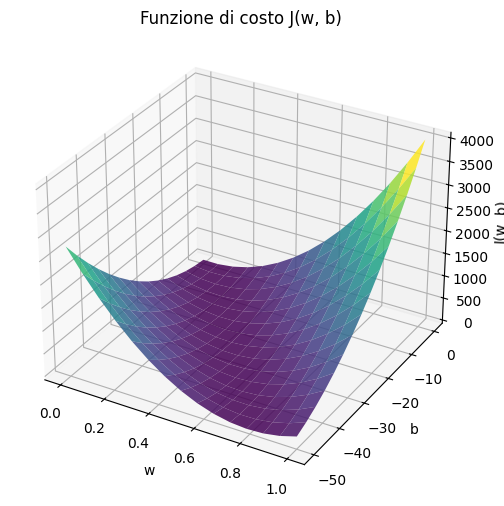

In [160]:
# Importiamo la libreria numerica per lavorare meglio
# con array e matrici,
import numpy as np

# Numero di punti per asse e intervalli
n = 15
w_min, w_max = 0.0, 1.0
b_min, b_max = -50, 0

# Costruiamo i due range per i parametri
w_values = np.linspace(w_min, w_max, n)
b_values = np.linspace(b_min, b_max, n)

# Costruiamo la griglia di valori (w, b)
W, B = np.meshgrid(w_values, b_values)

# Calcoliamo J in ogni punto della griglia
Z = np.array([[J(wi, bi) for wi in w_values] for bi in b_values])

# Disegniamo la superficie 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W, B, Z, cmap="viridis", alpha=0.85, edgecolor="none")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w, b)")
ax.set_title("Funzione di costo J(w, b)")
plt.show()

Nel caso della regressione lineare, questo apprendimento è particolarmente favorevole: esiste infatti una formula chiusa (nota come **metodo dei minimi quadrati**) che permette di calcolare direttamente i parametri ottimali risolvendo un problema algebrico. Tuttavia, questa soluzione analitica è un’eccezione più che la regola: per modelli più complessi non è disponibile, e diventa quindi necessario ricorrere a metodi più generali e spesso approssimati. Uno dei più utilizzati e che rappresenta un punto di partenza fondamentale è l’**algoritmo di discesa del gradiente**.

### Discesa del gradiente

Introduciamo un approccio iterativo, molto flessibile, chiamato **discesa del gradiente** (gradient descent). L’idea è semplice ma potente: invece di calcolare direttamente il minimo della funzione costo $\mathcal{J}(w,b)$, partiamo da una coppia iniziale di valori (scelti a caso) e li aggiorniamo progressivamente, muovendoci nella direzione che riduce l’errore. 

Dal punto di vista matematico, questo significa utilizzare il **gradiente** della funzione costo, cioè il vettore delle **derivate parziali**:

$\displaystyle \nabla \mathcal{J}(w,b) =
\left(
\frac{\partial \mathcal{J}}{\partial w},
\frac{\partial \mathcal{J}}{\partial b}
\right)$

Questa espressione, che può sembrare complessa, ha in realtà un significato molto intuitivo: il gradiente raccoglie, per ciascun parametro del modello (nel nostro caso w e b), l’informazione su come cambia la funzione costo quando quel parametro viene modificato:

$\displaystyle \frac{\partial \mathcal{J}}{\partial w} = \lim_{h \to 0} \frac{\mathcal{J}(w + h, b) - \mathcal{J}(w, b)}{h}$

$\displaystyle \frac{\partial \mathcal{J}}{\partial b} = \lim_{h \to 0} \frac{\mathcal{J}(w, b + h) - \mathcal{J}(w, b)}{h}$

Cioè, se modifichiamo leggermente un parametro, di quanto cambia la funzione costo? Questa variazione, normalizzata rispetto alla dimensione del cambiamento, ci dice in quale direzione conviene muoversi per ridurre l’errore.

Scriviamo una semplice implementazione del calcolo del gradiente per la nostra funzione costo lineare:

In [128]:
def gradiente(w, b, h=1e-5):
    
    # derivata rispetto a w
    dJ_dw = (J(w+h, b) - J(w, b)) / h
    
    # derivata rispetto a b
    dJ_db = (J(w, b+h) - J(w, b)) / h
    
    # Restituiamo le due derivate
    return dJ_dw, dJ_db

Il gradiente indica **la direzione di crescita più rapida della funzione**. Per trovare il minimo, dobbiamo quindi muoverci nella direzione opposta. Questo porta alla regola di aggiornamento:

$\displaystyle w \leftarrow w - \eta \frac{\partial \mathcal{J}}{\partial w}$

$\displaystyle b \leftarrow b - \eta \frac{\partial \mathcal{J}}{\partial b}$

dove $\eta$ è un parametro chiamato **learning rate**, che controlla la dimensione del passo: valori grandi producono aggiornamenti più rapidi ma rischiosi, valori piccoli aggiornamenti più lenti ma più stabili. 

Riassumendo, l'algoritmo della discesa del gradiente funziona in questo modo:

- inizializza i parametri con valori arbitrari
- ripete per più iterazioni:
    - valuta l’errore tramite la funzione costo
    - calcola il gradiente, cioè come cambiare i parametri
    - aggiorna i parametri nella direzione che riduce l’errore

Ripetendo questo processo, i parametri si avvicinano progressivamente a valori che rendono la funzione costo piccola: è così che **il modello impara dai dati**.

Prima di implementare l'algoritmo, però, vale la pena osservare con attenzione la forma della funzione costo che abbiamo visualizzato poco fa. La buona notizia è evidente: esiste una regione in cui il costo è chiaramente più bassa, ed è esattamente lì che vogliamo arrivare. La notizia meno favorevole si nota solo guardando bene: il fondo è una **valle lunga e stretta**. In una direzione la funzione è ripida e cambia rapidamente; nell'altra è quasi piatta e si estende per un lungo tratto. Questa asimmetria è una cattiva notizia per la discesa del gradiente, e si può capire intuitivamente. Il gradiente in ogni punto indica la direzione di pendenza massima, e l'algoritmo segue quella direzione. Ma in una valle allungata la pendenza massima punta quasi sempre **attraverso la valle, non lungo la valle**. Il risultato è che l'algoritmo zigzaga da una sponda all'altra, avanzando molto lentamente verso il fondo. Per non oscillare nella direzione ripida siamo costretti a usare passi piccolissimi; con passi piccolissimi, però, la direzione piatta non si muove praticamente mai.

Da dove viene questa asimmetria? Dal fatto che le nostre variabili **vivono su scale molto diverse**: l'overall è un numero fra circa 50 e 95, mentre il valore di mercato in milioni sta fra 0 e qualche decina. La soluzione standard, in machine learning, è semplice: **riscalare l'input prima di addestrare il modello**, in modo che le variabili lavorino tutte sulla stessa scala. Una trasformazione comune è la **normalizzazione min-max**, che porta la feature nell'intervallo $[0, 1]$:

$\displaystyle x' = \frac{x - \min(x)}{\max(x) - \min(x)}$

Una soluzione alternativa al riscalamento dei dati è cambiare l'algoritmo invece dei dati. Possiamo usare **due learning rate diversi**, uno per ciascun parametro: piccolo per la direzione ripida (così non oscilliamo), grande per la direzione piatta (così avanziamo davvero). È un trucco semplice ma efficace, e anticipa un'idea che gli algoritmi moderni implementano in modo automatico, scegliendo da soli un learning rate adattivo per ogni parametro. Noi possiamo scegliere le due learning rate guardando la curvatura della funzione costo nelle due direzioni, informazione che, in problemi reali, non si ha.

Vedremo la tecnica della normalizzazione più avanti. Per ora  non tocchiamo i dati e cambiamo invece l'algoritmo: useremo due learning rate diversi.

In [180]:
def gradient_descent(w_0, b_0, eta_w, eta_b, n_iter):
    
    # Inizializziamo i parametri
    w = w_0
    b = b_0

    # Memorizziamo il valore dell'errore ad ogni iterazione
    J_history = []

    # Memorizziamo anche la serie delle stime dei parametri
    w_history = []
    b_history = []

    # Eseguiamo un certo numero di iterazioni
    for step in range(n_iter):
        
        # Valutiamo l'errore attuale
        error = J(w, b)

        # Memorizziamo l'errore attuale
        J_history.append(error)

        # Memorizziamo i parametri attuali
        w_history.append(w)
        b_history.append(b)
        
        # Calcoliamo il gradiente
        grad_w, grad_b = gradiente(w, b)
        
        #  Aggiorniamo i parametri nella direzione opposta al gradiente
        w = w - eta_w * grad_w
        b = b - eta_b * grad_b

        # Stampiamo lo stato del training
        print(f"step = {step:3d} | J = {error:.4f} | w = {w:.4f} | b = {b:.4f}")
    
    # restituiamo i parametri finali dopo l'addestramento
    # e le storie di errore e parametri
    return w, b, J_history, w_history, b_history

Ora possiamo finalmente applicare l'algoritmo di discesa del gradiente, al nostro problema:

In [200]:
# Scegliamo dei valori iniziali per w e b
w_0 = 0.8
b_0 = -15.0

# Scegliamo due tassi di apprendimento diversi per w e b
eta_w = 0.00001
eta_b = 0.015

# Scegliamo un numero di iterazioni per l'addestramento
n_iter=30

w_finale, b_finale, J_history, w_history, b_history = gradient_descent(w_0, b_0, eta_w, eta_b, n_iter)

print(f"Parametri finali: w = {w_finale:.4f}, b = {b_finale:.4f}")

step =   0 | J = 1256.1755 | w = 0.7535 | b = -16.0557
step =   1 | J = 982.5950 | w = 0.7124 | b = -16.9883
step =   2 | J = 769.1181 | w = 0.6761 | b = -17.8120
step =   3 | J = 602.5405 | w = 0.6441 | b = -18.5397
step =   4 | J = 472.5587 | w = 0.6158 | b = -19.1825
step =   5 | J = 371.1329 | w = 0.5908 | b = -19.7503
step =   6 | J = 291.9897 | w = 0.5687 | b = -20.2519
step =   7 | J = 230.2337 | w = 0.5492 | b = -20.6950
step =   8 | J = 182.0450 | w = 0.5319 | b = -21.0864
step =   9 | J = 144.4431 | w = 0.5167 | b = -21.4322
step =  10 | J = 115.1020 | w = 0.5032 | b = -21.7376
step =  11 | J = 92.2071 | w = 0.4914 | b = -22.0074
step =  12 | J = 74.3420 | w = 0.4809 | b = -22.2457
step =  13 | J = 60.4018 | w = 0.4716 | b = -22.4562
step =  14 | J = 49.5241 | w = 0.4634 | b = -22.6422
step =  15 | J = 41.0363 | w = 0.4562 | b = -22.8065
step =  16 | J = 34.4131 | w = 0.4498 | b = -22.9516
step =  17 | J = 29.2451 | w = 0.4441 | b = -23.0798
step =  18 | J = 25.2125 | w = 0.4

Durante l’esecuzione, la funzione costo tende a diminuire progressivamente a ogni iterazione. Questo accade perché, a ogni passo, i parametri vengono aggiornati nella direzione che riduce l’errore. All’inizio, partendo da valori arbitrari di w e b, l’errore può essere anche molto elevato. Con il procedere delle iterazioni, però, il modello corregge gradualmente le proprie previsioni: ogni aggiornamento è un piccolo passo verso una configurazione migliore. Possiamo usare il vettore in cui abbiamo memorizzato la storia dell'errore per visualizzare questa tendenza:



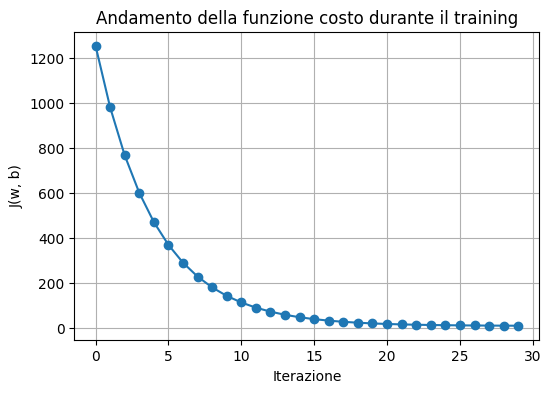

In [201]:
plt.figure(figsize=(6,4))
plt.plot(J_history, marker='o')
plt.xlabel("Iterazione")
plt.ylabel("J(w, b)")
plt.title("Andamento della funzione costo durante il training")
plt.grid(True)
plt.show()

In una situazione ideale, osserviamo un comportamento tipico:

- nelle prime iterazioni, la funzione costo diminuisce rapidamente
- successivamente, la discesa rallenta
- infine, i valori si stabilizzano intorno a un minimo

Questo comportamento riflette il fatto che il modello si sta progressivamente avvicinando alla soluzione ottimale: quando i parametri sono lontani dal minimo, è relativamente facile ridurre l’errore; man mano che ci si avvicina, invece, i miglioramenti diventano sempre più piccoli e graduali. Possiamo rendere questa dinamica ancora più evidente visualizzando, a ogni iterazione, il punto corrispondente ai valori dei parametri: in questo modo osserviamo direttamente come la sequenza degli aggiornamenti si muove nello spazio dei parametri e converge verso il minimo della funzione costo.

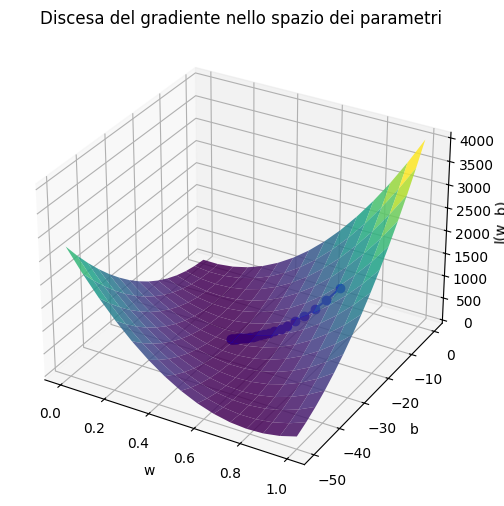

In [235]:
# Disegniamo la superficie 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Disegnamo la funzione costo
ax.plot_surface(W, B, Z, cmap="viridis", alpha=0.85, edgecolor="none")
    
# Prepariamo i punti del percorso di discesa del gradiente
J_path = [J(wi, bi) for wi, bi in zip(w_history, b_history)]

# Disegniamo il percorso di discesa del gradiente
ax.plot(w_history, b_history, J_path, marker='o', color='b')
    
# Impostiamo le etichette e il titolo
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w, b)")
ax.set_title("Discesa del gradiente nello spazio dei parametri")
plt.show()

È importante sottolineare che finora abbiamo lavorato in una situazione molto favorevole: il nostro modello ha solo due parametri e questo ci ha permesso di visualizzare direttamente la funzione costo come una superficie. Questo è estremamente utile per costruire intuizione, ma è un caso speciale. **Cosa succede quando il modello ha più parametri?**

Se, ad esempio, utilizziamo più feature, il modello lineare diventerebbe:

$\displaystyle \hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_d x_d + b$

In questo caso, la funzione costo dipende da molti parametri e la visualizzazione diventa impossibile! In generale, lavoriamo in spazi ad alta dimensionalità, che non possiamo più rappresentare graficamente.

Inoltre nel nostro esempio, la funzione costo ha una forma molto regolare: una "ciotola" con un unico minimo globale. Questa è una proprietà specifica della regressione lineare. Tuttavia, questa situazione è tutt’altro che generale. Per modelli più complessi (ad esempio **reti neurali**), la funzione costo può avere **una forma molto più articolata**:

- può contenere più minimi locali
- può presentare superfici molto irregolari

In questi casi, l’algoritmo di training non è più garantito a trovare il minimo globale, ma può fermarsi in una soluzione "sufficientemente buona".

### Dove sbaglia il modello? 

Per capire cosa ha imparato il modello, disegniamolo in azione. Se il modello ha imparato bene, la retta dovrebbe attraversare la nuvola dei punti seguendone la tendenza generale:

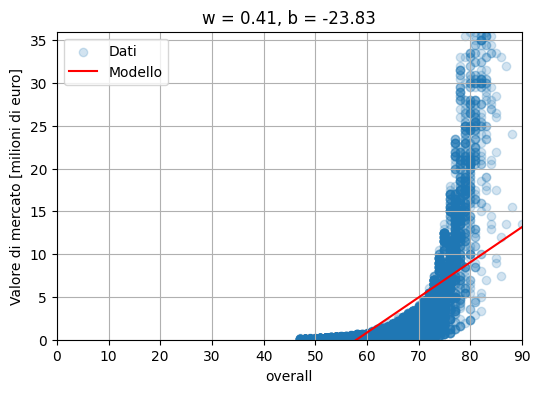

In [203]:
plot_line_with_data(w_finale, b_finale)

Una retta che passa nel mezzo della nuvola sembra ragionevole, ma per giudicarla davvero non basta uno sguardo d'insieme: dobbiamo guardare gli **errori giocatore per giocatore**, per questo i residui possono venire in aiuto. Per ogni calciatore reale calcoliamo la differenza tra il valore vero e la previsione del modello, e disegniamo questi residui in funzione dell'overall. La forma che assumeranno ci dirà dove il modello sbaglia in modo sistematico.

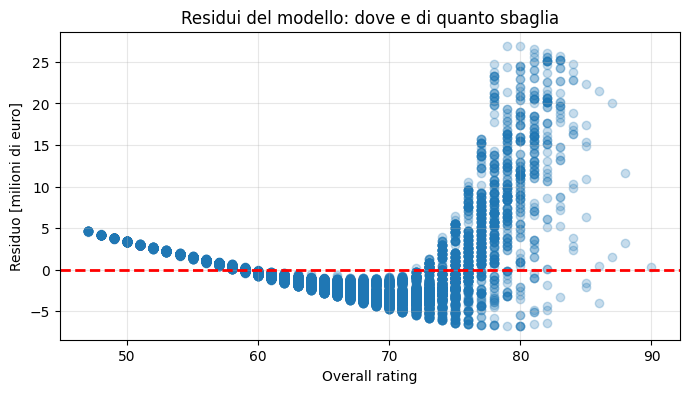

In [205]:
# Calcola il valore stimato per ogni giocatore
y_hat = w_finale * x + b_finale

# Calcola il residuo per ogni giocatore
residui = y - y_hat

# Disegniamo i residui in funzione dell'overall
plt.figure(figsize=(8,4))
plt.scatter(x, residui, alpha=0.25)

# Disegnamo una linea rossa per evidenziare l'errore zero: la previsione perfetta.
# Punti sopra = sottostime, punti sotto = sovrastime.
plt.axhline(0, color="red", linestyle="--", linewidth=2)

# Aggiungiamo titolo, etichette e griglia
plt.xlabel("Overall")
plt.ylabel("Residuo [milioni di euro]")
plt.title("Residui del modello: dove e di quanto sbaglia")
plt.grid(True, alpha=0.3)
plt.show()


Idealmente, i residui dovrebbero essere distribuiti casualmente attorno a zero, senza mostrare alcuna struttura: significherebbe che il modello sta catturando bene la relazione tra le variabili e gli errori sono dovuti principalmente a rumore. Nel nostro caso, però, emerge un andamento ben riconoscibile: i residui non sono distribuiti in modo casuale, ma seguono una sorta di curvatura. Questo indica che **il modello lineare non riesce a descrivere completamente il fenomeno**: esiste ancora una struttura nei dati che la retta non è in grado di catturare. In altre parole, il legame tra overall e valore di mercato non è perfettamente lineare. Inoltre, nella parte destra del grafico (per valori alti di overall) si nota una maggiore dispersione dei residui, che suggerisce una variabilità crescente dell’errore: il modello è meno preciso proprio dove i valori sono più elevati. Infine, alcuni punti molto distanti dalla linea dello zero indicano errori particolarmente grandi: si tratta di giocatori "atipici" (**outlier**), il cui valore non è ben spiegato dal modello e che potrebbero richiedere un’analisi più approfondita.

Possiamo anche introdurre una **misura sintetica della qualità del modello** calcolando un **errore medio** su tutto il dataset. L’idea è quella di aggregare i residui in un unico numero che quantifichi quanto, in media, le previsioni si discostano dai valori reali, mantenendo una scala interpretabile. Ad esempio possiamo considerare l’**errore medio assoluto (MAE)**:

$\displaystyle \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \bigl|y_i - \hat{y}_i\bigr|$

In questo caso, il valore ottenuto indica di quanto, in media, le previsioni del modello si discostano dai valori reali, fornendo un’indicazione immediata della qualità dello scout automatico.

In [210]:
# Numero totale di giocatori nel dataset
n = len(x)

# Inizializziamo l'errore totale a zero
error = 0.0

# Scorriamo tutti i giocatori, uno alla volta
for xi, yi in zip(x, y):
    
    # Calcoliamo la previsione del modello per il giocatore corrente
    y_hat = w_finale * xi + b_finale
    
    # Aggiungiamo l'errore assoluto tra valore reale e previsto
    error += abs(yi - y_hat)

# Calcoliamo la media degli errori
mae = error / n

# Stampiamo il risultato
print(f"MAE = {mae:.2f} milioni di euro")

MAE = 2.32 milioni di euro


Come valutiamo questo errore? Il nostro modello in media sbaglia di circa 2 milioni di euro nella valutazione del valore di mercato. È un errore grande o piccolo? Per rispondere a questa domanda, è utile confrontare questo risultato con un **modello di riferimento** (baseline), che rappresenta una strategia semplice e intuitiva per fare previsioni. Ad esempio, potremmo considerare un modello che prevede in modo casuale:

In [234]:
import random

n = len(x)

error = 0.0

# intervallo realistico dei valori
y_min = y.min()
y_max = y.max()

for yi in y:
    
    # previsione casuale
    y_hat = random.uniform(y_min, y_max)
    
    # errore assoluto
    error += abs(yi - y_hat)

mae_random = error / n

print(f"MAE modello casuale = {mae_random:.2f} milioni di euro")

MAE modello casuale = 16.37 milioni di euro


Il valore ottenuto per il modello casuale è molto alto: un errore medio di circa 16 milioni di euro significa che, in media, le sue previsioni sono lontanissime dai valori reali. Questo numero è utile perché fornisce un punto di riferimento: rappresenta il livello di errore di un modello che non ha imparato nulla dai dati. **Qualsiasi modello sensato dovrebbe fare significativamente meglio di questo**. Il nostro scout automatico è circa sette volte più preciso di una strategia che non utilizza alcuna informazione. Un risultato di questo tipo indica chiaramente che **il modello ha imparato qualcosa** dai dati: non si limita a indovinare, ma sfrutta la relazione tra overall e valore di mercato per produrre stime molto più vicine alla realtà.

## Facciamo scouting!

Finora abbiamo valutato il modello usando misure aggregate, cioè numeri che riassumono l’errore su tutto il dataset. Ma per capire davvero come si comporta il nostro scout automatico è utile osservarlo giocatore per giocatore.

Estraiamo quindi dieci calciatori a caso e, per ciascuno, confrontiamo tre quantità: il valore reale di mercato, la previsione del modello e l’errore commesso. In questo modo possiamo vedere concretamente dove il modello è convincente, dove sbaglia di poco e dove invece produce stime molto lontane dalla realtà.

In [206]:
# Estraiamo 10 giocatori a caso
sample = dataset.sample(10).copy()

# Chiediamo al modello la sua previsione per ognuno
sample["predicted_value_mln_eur"] = w_finale * sample["overall"] + b_finale

# Calcoliamo l'errore: previsione - valore reale
sample["error_mln_eur"] = (sample["predicted_value_mln_eur"] - sample["value_mln_eur"])

# Mostriamo la tabella riassuntiva, arrotondata a 2 decimali
sample[[
    "short_name", "age", "overall", "potential",
    "value_mln_eur", "predicted_value_mln_eur", "error_mln_eur"
]].round(2)


,short_name,age,overall,potential,value_mln_eur,predicted_value_mln_eur,error_mln_eur
1120,M. Kudus,20,77,86,23.00,7.82,-15.18
7585,Ortuño,30,67,67,1.00,3.71,2.71
13396,A. Williams,34,62,62,0.19,1.65,1.46
6495,Laure,36,68,68,0.28,4.12,3.84
8343,I. Sissoko,25,67,70,1.40,3.71,2.31
14752,C. Mesías,23,61,71,0.68,1.24,0.57
8685,P. Hartley,33,66,66,0.40,3.30,2.90
18511,R. Murillo,19,53,70,0.24,-2.05,-2.29
15329,D. Pierias,21,60,71,0.55,0.83,0.28
3391,D. Biraschi,26,72,74,2.60,5.76,3.16


> **Cosa dovremmo aver capito** — Abbiamo costruito il nostro primo modello predittivo: una retta che, dato l'overall di un giocatore, restituisce una stima del suo valore di mercato. Lungo la strada abbiamo incontrato i tre ingredienti che caratterizzano qualunque algoritmo di machine learning: una formula con dei parametri, una funzione costo che misura quanto il modello sbaglia, e un algoritmo di apprendimento che cerca i parametri migliori. Il modello finale funziona meglio che tirare a caso, ma resta limitato: uno scout vero non guarda mai un solo numero.

> **Cosa faremo adesso** — Nel prossimo notebook trasformeremo lo scout in qualcosa di più realistico: gli daremo da guardare quattro indizi insieme (età, overall, potential, salario) e vedremo se l'errore diminuisce davvero. Ne approfitteremo anche per imparare a confrontare i pesi del modello, scoprendo quale tra questi indizi pesa di più sul valore di un calciatore.